<a href="https://colab.research.google.com/github/Akshatha7710/smart-tea-estate-management-system/blob/soil_quality-analysis_and_predictive_modeling/Soil_Quality_Analysis_and_Predictive_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits

MODEL COMPARISON
           Model       MAE      RMSE        R2
0  Random Forest  0.483776  0.636086  0.291103
1        XGBoost  0.505301  0.621344  0.323581


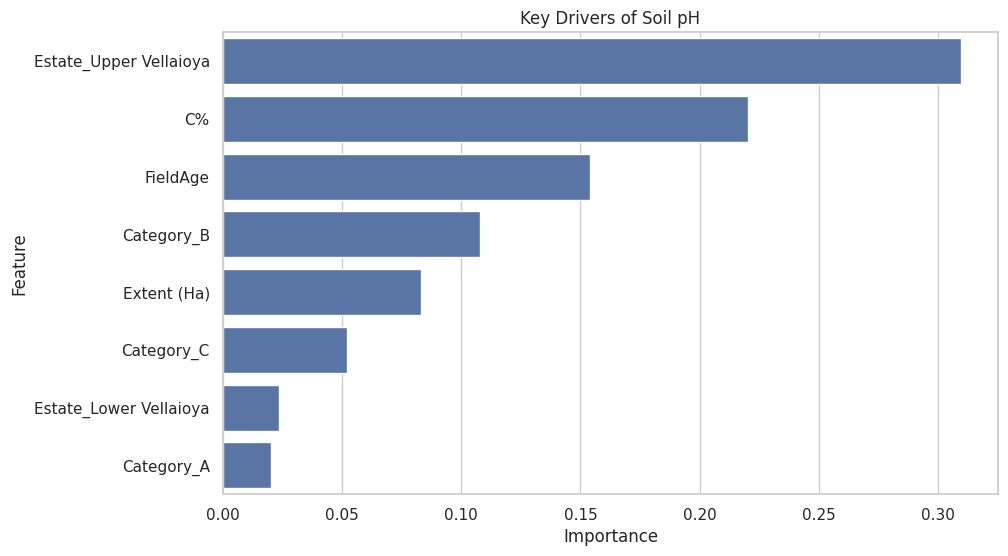

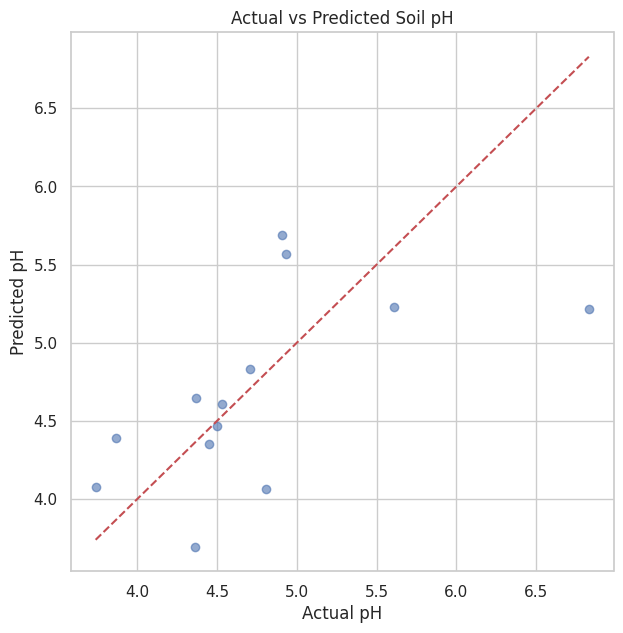

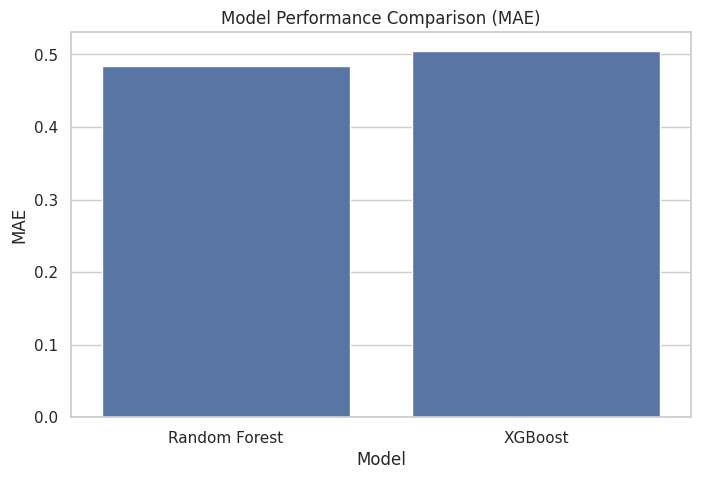


WET DAYS MODEL
MAE : 3.015997932009075
RMSE: 4.013622612999881
R2  : 0.700065146145997


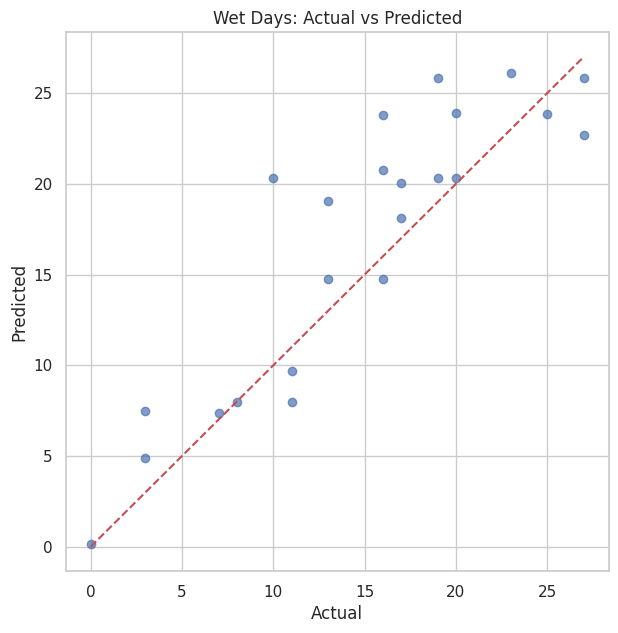

In [2]:
# ==========================================================
# STEMS - Smart Tea Estate Management System
# Final Clean Version (Soil + Wet Days + Tuning)
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from scipy.stats import uniform, randint

sns.set_theme(style="whitegrid")

# ==========================================================
# 1. LOAD & PREPROCESS SOIL DATA
# ==========================================================
soil = pd.read_csv("sample_data/soil_data.csv")

soil.replace("missing", np.nan, inplace=True)
soil["pH"] = pd.to_numeric(soil["pH"], errors="coerce")
soil["C%"] = pd.to_numeric(soil["C%"], errors="coerce")
soil["Year of Planting"] = pd.to_numeric(soil["Year of Planting"], errors="coerce")

soil = soil.dropna()
soil["FieldAge"] = 2025 - soil["Year of Planting"]

features = ["Extent (Ha)", "Category", "VP/SD", "Estate", "FieldAge", "C%"]
X = soil[features]
y = soil["pH"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================================================
# 2. PREPROCESSING PIPELINE
# ==========================================================
categorical_cols = ["Category", "VP/SD", "Estate"]
numeric_cols = ["Extent (Ha)", "FieldAge", "C%"]

preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", StandardScaler(), numeric_cols)
])

# ==========================================================
# 3. RANDOM FOREST (GRID SEARCH TUNING)
# ==========================================================
rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

rf_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [5, 8, 12]
}

rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=5,
                       scoring='r2', n_jobs=-1, verbose=1)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

rf_preds = best_rf.predict(X_test)

rf_results = {
    "Model": "Random Forest",
    "MAE": mean_absolute_error(y_test, rf_preds),
    "RMSE": np.sqrt(mean_squared_error(y_test, rf_preds)),
    "R2": r2_score(y_test, rf_preds)
}

# ==========================================================
# 4. XGBOOST (RANDOM SEARCH TUNING)
# ==========================================================
xgb_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", xgb.XGBRegressor(random_state=42, tree_method='hist'))
])

xgb_param_dist = {
    'model__n_estimators': randint(100, 800),
    'model__max_depth': randint(3, 12),
    'model__learning_rate': uniform(0.01, 0.2),
    'model__subsample': uniform(0.6, 0.4),
    'model__colsample_bytree': uniform(0.6, 0.4)
}

xgb_random = RandomizedSearchCV(
    xgb_pipeline,
    xgb_param_dist,
    n_iter=30,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

xgb_random.fit(X_train, y_train)

best_xgb = xgb_random.best_estimator_

xgb_preds = best_xgb.predict(X_test)

xgb_results = {
    "Model": "XGBoost",
    "MAE": mean_absolute_error(y_test, xgb_preds),
    "RMSE": np.sqrt(mean_squared_error(y_test, xgb_preds)),
    "R2": r2_score(y_test, xgb_preds)
}

# ==========================================================
# 5. MODEL COMPARISON
# ==========================================================
comparison_df = pd.DataFrame([rf_results, xgb_results]).sort_values(by="MAE")

print("\nMODEL COMPARISON")
print(comparison_df)

# ==========================================================
# 6. VISUALIZATIONS (FOR REPORT)
# ==========================================================

# --- Feature Importance (Random Forest) ---
plt.figure(figsize=(10,6))

ohe_names = list(best_rf.named_steps['prep'].transformers_[0][1].get_feature_names_out())
all_features = ohe_names + numeric_cols

importances = best_rf.named_steps['model'].feature_importances_

feat_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).head(8)

sns.barplot(x="Importance", y="Feature", data=feat_df)
plt.title("Key Drivers of Soil pH")
plt.show()

# --- Actual vs Predicted ---
plt.figure(figsize=(7,7))
plt.scatter(y_test, rf_preds, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual pH")
plt.ylabel("Predicted pH")
plt.title("Actual vs Predicted Soil pH")
plt.show()

# --- Model Comparison ---
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="MAE", data=comparison_df)
plt.title("Model Performance Comparison (MAE)")
plt.show()

# ==========================================================
# 7. WET DAYS PREDICTION MODEL
# ==========================================================
rain = pd.read_csv("sample_data/rainfall_data.csv")

rain.columns = rain.columns.str.strip().str.replace(" ", "_")
rain.replace(["missing", "NA", "-"], np.nan, inplace=True)

rain["Rainfall"] = pd.to_numeric(rain["Rainfall"], errors="coerce")
rain["Wet_days"] = pd.to_numeric(rain["Wet_days"], errors="coerce")

rain = rain.dropna()

X_rain = rain[["Rainfall"]]
y_rain = rain["Wet_days"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_rain, y_rain, test_size=0.2, random_state=42
)

wet_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

wet_model.fit(Xr_train, yr_train)

wet_preds = wet_model.predict(Xr_test)

print("\nWET DAYS MODEL")
print("MAE :", mean_absolute_error(yr_test, wet_preds))
print("RMSE:", np.sqrt(mean_squared_error(yr_test, wet_preds)))
print("R2  :", r2_score(yr_test, wet_preds))

# --- Wet Days Visualization ---
plt.figure(figsize=(7,7))
plt.scatter(yr_test, wet_preds, alpha=0.7)
plt.plot([yr_test.min(), yr_test.max()],
         [yr_test.min(), yr_test.max()], 'r--')
plt.title("Wet Days: Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()